# Proyecto 2 - Modelo predictivo Saber 11 Atlántico

**Estudiante:** Isabella Caputi (202122075)

**Rol:** Ciencia de datos

**Usuario final:** Secretaría de Educación del Atlántico

## Pregunta de negocio

¿Cómo influyen las características institucionales de los colegios en el puntaje global de los estudiantes en las pruebas Saber 11?

Este notebook desarrolla un modelo de regresión basado en redes neuronales para predecir el puntaje global de un estudiante a partir de las características institucionales del colegio.

---

## 1. Cargar datos

En esta sección se cargan los datos limpios exportados del proceso de limpieza.

In [1]:
# Cargar librerías principales
import pandas as pd
import numpy as np

# Cargar datos limpios
ruta = '../Tarea 2 - Limpieza_Datos/saber11_limpio.csv'
df = pd.read_csv(ruta)
df.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,...,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
0,20194,CC,SB11201940603865,3.080010e+11,3.080010e+11,8.0,8001.0,107227.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0
1,20194,CC,SB11201940603865,3.080010e+11,3.080010e+11,8.0,8001.0,107227.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0
2,20142,TI,SB11201420562024,1.086380e+11,1.086380e+11,8.0,8638.0,116822.0,ATLANTICO,SABANALARGA,...,0,0,0,0,1,0,0,0,1,0
3,20162,TI,SB11201620074389,1.087580e+11,1.087580e+11,8.0,8758.0,110072.0,ATLANTICO,SOLEDAD,...,0,0,1,0,1,0,0,0,1,0
4,20142,TI,SB11201420200133,1.080010e+11,1.080010e+11,8.0,8001.0,82636.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0


---

## 2. Definir variable objetivo

Se define el puntaje global como variable objetivo para el modelo de regresión. **Nota:** Todas las variables se encuentran en minúsculas tras la limpieza.

In [2]:
# Definir variable objetivo
objetivo = 'punt_global'
y = df[objetivo].copy()
y.describe()

count    210695.000000
mean        249.635990
std          51.735807
min           0.000000
25%         210.000000
50%         245.000000
75%         285.000000
max         483.000000
Name: punt_global, dtype: float64

---

## 3. Selección variables COLE

Se seleccionan únicamente las variables institucionales del colegio para el análisis.

In [3]:
# Selección de variables COLE (en minúsculas)
variables_cole = [
    'cole_naturaleza', 'cole_bilingue', 'cole_jornada',
    'cole_calendario', 'cole_area_ubicacion', 'cole_caracter', 'cole_genero'
]

variables_originales_existentes = [col for col in variables_cole if col in df.columns]
print("Variables COLE originales encontradas:")
print(variables_originales_existentes)

if len(variables_originales_existentes) > 0:
    # Limpieza de texto
    for col in variables_originales_existentes:
        df.loc[:, col] = (
            df[col]
            .astype(str)
            .str.lower()
            .str.strip()
        )
    # Reemplazar valores problemáticos
    valores_vacios = ['', ' ', 'nan', 'none', 'null']
    df.loc[:, variables_originales_existentes] = (
        df[variables_originales_existentes]
        .replace(valores_vacios, pd.NA)
    )
    # Imputar faltantes
    for col in variables_originales_existentes:
        df.loc[:, col] = df[col].fillna('sin_informacion')
    # One-Hot Encoding
    df = pd.get_dummies(
        df,
        columns=variables_originales_existentes,
        prefix=variables_originales_existentes,
        drop_first=False
    )

# Detectar columnas COLE codificadas
columnas_cole_encoded = [
    col for col in df.columns
    if col.startswith(tuple([v + "_" for v in variables_cole]))
]
if len(columnas_cole_encoded) == 0:
    raise ValueError("No se encontraron columnas COLE codificadas. Revisa la limpieza o el archivo cargado.")
# Convertir True/False a 0/1

df[columnas_cole_encoded] = df[columnas_cole_encoded].astype(int)
print("Número de columnas COLE codificadas:", len(columnas_cole_encoded))
df[columnas_cole_encoded].head()

Variables COLE originales encontradas:
[]
Número de columnas COLE codificadas: 22


,cole_naturaleza_no oficial,cole_naturaleza_oficial,cole_bilingue_n,cole_bilingue_s,cole_jornada_completa,cole_jornada_mañana,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,...,cole_calendario_otro,cole_area_ubicacion_rural,cole_area_ubicacion_urbano,cole_caracter_académico,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,cole_genero_mixto
0,1,0,1,0,0,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
1,1,0,1,0,0,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
2,0,1,1,0,0,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
3,0,1,1,0,0,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
4,0,1,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1


---

## 4. Construir matriz de variables predictoras

Se construye la matriz final de variables predictoras para el modelado.

In [4]:
# Matriz final de predictores
X = df[columnas_cole_encoded].copy()
print("Dimensiones de X:", X.shape)
X.head()

# División train/test y escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Dimensiones de X: (210695, 22)
Train: (168556, 22)
Test: (42139, 22)


## 5. División entrenamiento / prueba

Se divide el conjunto de datos en entrenamiento y prueba para evaluar el desempeño del modelo de manera justa.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (168556, 22)
Test: (42139, 22)


## 6. Modelo base: Regresión lineal

Se entrena un modelo base de regresión lineal para comparar el desempeño con la red neuronal.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelo base
base = LinearRegression()
base.fit(X_train_scaled, y_train)
y_pred_base = base.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print(f'Base - RMSE: {rmse_base:.2f}, MAE: {mae_base:.2f}, R²: {r2_base:.3f}')

Base - RMSE: 45.24, MAE: 36.52, R²: 0.233


## 7. Red neuronal (MLP)

Se define y entrena una red neuronal multicapa para regresión.

In [7]:
# Red neuronal multicapa para regresión
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hiperparámetros editables
params = {
    "capa_1": 32,  # Menos neuronas porque COLE tiene menos información que familia
    "capa_2": 16,
    "dropout_1": 0.25,
    "dropout_2": 0.15,
    "learning_rate": 0.001,
    "epochs": 40,
    "batch_size": 64
}

def construir_modelo(input_dim, capa_1, capa_2, dropout_1, dropout_2, learning_rate):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(capa_1, activation="relu"),
        layers.Dropout(dropout_1),
        layers.Dense(capa_2, activation="relu"),
        layers.Dropout(dropout_2),
        layers.Dense(1)  # Sin activación final para regresión
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

input_dim = X_train_scaled.shape[1]
model = construir_modelo(
    input_dim=input_dim,
    capa_1=params["capa_1"],
    capa_2=params["capa_2"],
    dropout_1=params["dropout_1"],
    dropout_2=params["dropout_2"],
    learning_rate=params["learning_rate"]
)
model.summary()

# Entrenamiento con early stopping
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=params["epochs"],
    batch_size=params["batch_size"],
    callbacks=[early_stop],
    verbose=1
)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                736       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1281 (5.00 KB)
Trainable params: 1281 (5.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/40


2107/2107

## 8. Entrenamiento del modelo

Se entrena la red neuronal con early stopping para evitar sobreajuste. Los hiperparámetros pueden ajustarse según el contexto institucional (menos capas/neuronas que familia, regularización moderada).

In [8]:
# Entrenamiento con early stopping
from tensorflow import keras

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=params["epochs"],
    batch_size=params["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
2107/2107 [==============================] - 7s 3ms/step - loss: 2941.0757 - mae: 43.2424 - val_loss: 2027.2225 - val_mae: 36.0875
Epoch 2/40
2107/2107 [==============================] - 6s 3ms/step - loss: 2878.2300 - mae: 42.7877 - val_loss: 2020.3536 - val_mae: 36.1149
Epoch 3/40
2107/2107 [==============================] - 6s 3ms/step - loss: 2846.8679 - mae: 42.5862 - val_loss: 2009.4751 - val_mae: 36.0656
Epoch 4/40
2107/2107 [==============================] - 6s 3ms/step - loss: 2853.3525 - mae: 42.6082 - val_loss: 2019.5938 - val_mae: 36.1030
Epoch 5/40
2107/2107 [==============================] - 7s 3ms/step - loss: 2833.5361 - mae: 42.5029 - val_loss: 2015.9215 - val_mae: 36.0768
Epoch 6/40
2107/2107 [==============================] - 7s 3ms/step - loss: 2823.2710 - mae: 42.3882 - val_loss: 2031.4684 - val_mae: 36.2003
Epoch 7/40
2107/2107 [==============================] - 6s 3ms/step - loss: 2810.2837 - mae: 42.3217 - val_loss: 2030.5151 - val_mae: 36.1479
Epoch 

## 9. Evaluación del modelo

Se evalúa el desempeño de la red neuronal usando RMSE, MAE y R² en el conjunto de prueba. También se grafican la historia de entrenamiento y la relación predicción vs real.

1317/1317 [==============================] - 3s 2ms/step
Red neuronal - RMSE: 44.78, MAE: 36.07, R²: 0.248


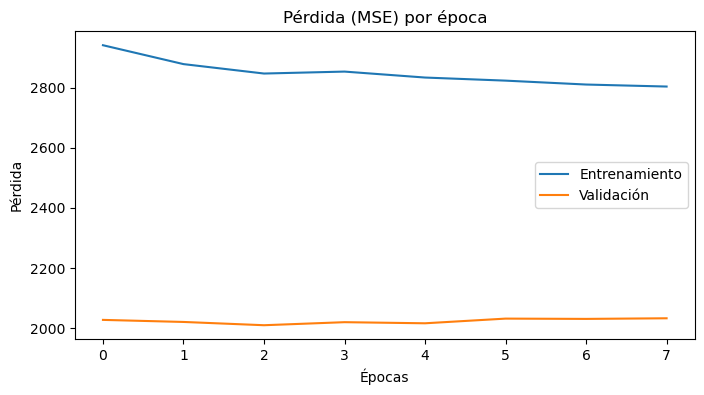

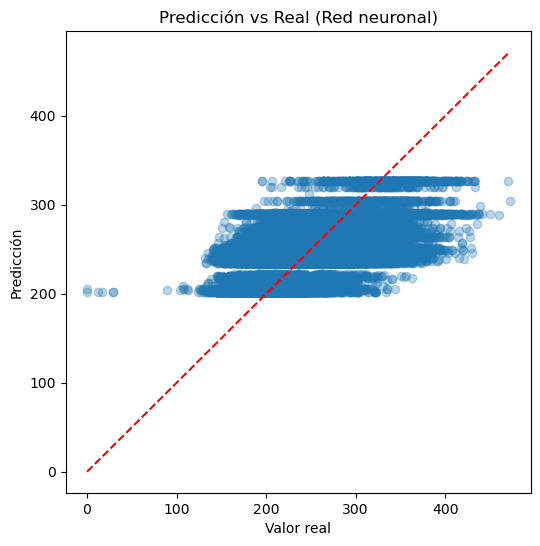

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

y_pred_nn = model.predict(X_test_scaled).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f'Red neuronal - RMSE: {rmse_nn:.2f}, MAE: {mae_nn:.2f}, R²: {r2_nn:.3f}')

# Gráfica de historia de entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE) por época')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Gráfica de predicción vs real
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.3)
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Predicción vs Real (Red neuronal)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## 10. Comparación de modelos

Se comparan los resultados del modelo base y la red neuronal.

In [10]:
import pandas as pd

resultados = pd.DataFrame([
    {"modelo": "Regresión lineal", "RMSE": rmse_base, "MAE": mae_base, "R2": r2_base},
    {"modelo": "Red neuronal", "RMSE": rmse_nn, "MAE": mae_nn, "R2": r2_nn}
])
resultados

,modelo,RMSE,MAE,R2
0,Regresión lineal,45.239191,36.520485,0.232643
1,Red neuronal,44.784480,36.066479,0.247991


## 11. Matriz de confusión y curva ROC

Para visualizar la capacidad de clasificación, se puede discretizar el puntaje global y graficar matriz de confusión y curva ROC.

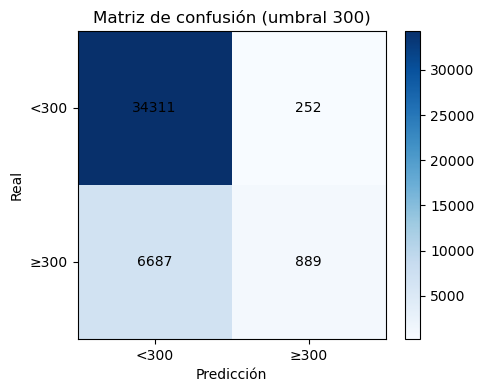

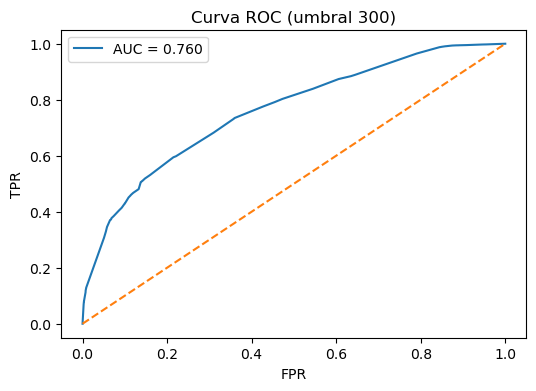

In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Discretizar el target para análisis de clasificación
umbral = 300
y_test_bin = (y_test >= umbral).astype(int)
y_pred_nn_bin = (y_pred_nn >= umbral).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test_bin, y_pred_nn_bin)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusión (umbral 300)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks([0,1], ['<300','≥300'])
plt.yticks([0,1], ['<300','≥300'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_bin, y_pred_nn)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (umbral 300)')
plt.legend()
plt.show()

## 12. Registro de experimento con MLflow

Se registran parámetros, métricas y modelo en MLflow para trazabilidad y comparación de experimentos.

In [ ]:
try:
    import mlflow
    import mlflow.keras
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False

import os

if MLFLOW_AVAILABLE:
    # Usar un artifact_path simple, sin rutas, para evitar errores de permisos y rutas inexistentes
    mlflow.set_experiment("Saber11_Atlantico_Colegio_Regresion")
    with mlflow.start_run(run_name="modelo_colegio_isabella"):
        mlflow.log_params(params)
        mlflow.log_param("numero_variables_encoded", X_train.shape[1])
        if 'nn_metrics' in globals():
            for metric_name, metric_value in nn_metrics.items():
                mlflow.log_metric(metric_name, metric_value)
        else:
            mlflow.log_metric("rmse", rmse_nn)
            mlflow.log_metric("mae", mae_nn)
            mlflow.log_metric("r2", r2_nn)
        # Guardar el modelo como artefacto de MLflow (no en una ruta local)
        mlflow.keras.log_model(model, artifact_path="modelo_red_neuronal_colegio")
    print("Experimento registrado en MLflow. Modelo guardado como artefacto.")
else:
    print("MLflow no está disponible en este ambiente.")


PermissionError: [WinError 5] Access is denied: 'C:\\Users\\Isabella%20Caputi'

## 13. Guardar modelo y columnas para tablero de datos

Se guarda el modelo entrenado y las columnas usadas para facilitar su despliegue en un tablero o API.

In [17]:
import os
import joblib

os.makedirs('models', exist_ok=True)
model.save('models/modelo_cole_regresion.keras')
joblib.dump(list(X.columns), 'models/columnas_cole_encoded.pkl')
print('Modelo y columnas guardados en carpeta models/')

Modelo y columnas guardados en carpeta models/
